# No preamble

In [1]:
from commstools import Signal, load_npz
from commstools.backend import dispatch
from commstools.equalization import lms, block_lms
from commstools.sync import (
    compensate_iq_imbalance_lowdin,
    correct_carrier_phase,
    correct_frequency_offset,
    correct_timing,
    estimate_timing,
    recover_carrier_phase_bps,
    recover_carrier_phase_pll,
)

TX_PATH = "/home/lokgar/repos/trmhi304-p2p/waveforms/signal_16qam"
RX_PATH = "/home/lokgar/repos/trmhi304-p2p/captures/capture_16qam_intradyne_long.npy"


2026-05-18 18:40:20 [INFO] [commstools/backend.py] CuPy is available and functional, defaulting Signals to GPU.


In [2]:
def find_bias_tone(seg_1d_cpu, fs, xp, target_hz=None, search_band_hz=None):
    """
    Sub-bin PSD-peak FOE.

    Locate the strongest spectral peak in `seg_1d_cpu` and refine its
    position via log-parabolic fit on the three bins around the argmax.
    Returns the refined peak frequency in Hz.

    Optional restriction: pass both ``target_hz`` and ``search_band_hz`` to
    limit the search to ``[target_hz ± search_band_hz]``.  Useful for
    tracking the bias tone after a coarse correction has placed it near a
    known target frequency, so the wider-band signal doesn't fool argmax.

    Parameters
    ----------
    seg_1d_cpu : 1-D complex numpy array (CPU)
    fs : sampling rate in Hz
    target_hz, search_band_hz : optional band restriction in Hz
    """
    x = xp.asarray(seg_1d_cpu)
    N = len(x)
    spec = xp.fft.fftshift(xp.fft.fft(x))
    Pxx = spec.real**2 + spec.imag**2
    f = xp.fft.fftshift(xp.fft.fftfreq(N, d=1.0 / fs))

    if target_hz is not None and search_band_hz is not None:
        band = xp.where(xp.abs(f - target_hz) < search_band_hz)[0]
        k = int(band[int(xp.argmax(Pxx[band]))])
    else:
        k = int(xp.argmax(Pxx))

    if 0 < k < N - 1:
        ym = xp.log(max(Pxx[k - 1], 1e-30))
        y0 = xp.log(max(Pxx[k], 1e-30))
        yp = xp.log(max(Pxx[k + 1], 1e-30))
        denom = ym - 2.0 * y0 + yp
        delta = 0.5 * (ym - yp) / denom if abs(denom) > 1e-30 else 0.0
    else:
        delta = 0.0
    return float(f[k] + delta * (fs / N))


def piecewise_carrier_phase(samples_1d, fs, block_size, overlap, estimator, xp, sp):
    """
    Build a per-sample carrier-phase trajectory from a per-block FOE.

    Mirrors the structure of `estimate_frequency_offset_blockwise` (overlap,
    cubic-spline interpolation between block centres, ``cumsum``-to-phase)
    but accepts an arbitrary per-block estimator callable.

    Parameters
    ----------
    samples_1d : (N,) complex array
    fs : sampling rate (Hz)
    block_size : analysis block length in samples
    overlap : fractional overlap in ``[0, 1)``
    estimator : callable ``(block_1d_cpu, fs) -> df_hz``

    Returns
    -------
    theta : (N,) float64 — per-sample phase trajectory in radians.
            Apply via ``correct_carrier_phase(samples, theta)``.
    """
    N = len(samples_1d)
    step = max(1, round(block_size * (1.0 - overlap)))
    starts = list(range(0, N - block_size + 1, step)) or [0]

    t_centers = xp.array([s + block_size / 2.0 for s in starts], dtype=xp.float64)
    dfs = xp.array(
        [estimator(samples_1d[s : s + block_size], fs) for s in starts],
        dtype=xp.float64,
    )
    print(
        f"    per-segment Δf:  mean = {dfs.mean():+.1f} Hz,  "
        f"std = {dfs.std():.1f} Hz,  "
        f"range = [{dfs.min():+.1f}, {dfs.max():+.1f}] Hz "
        f"({len(starts)} segments)"
    )

    n_grid = xp.arange(N, dtype=xp.float64)

    if len(starts) >= 2:
        spline = sp.interpolate.PchipInterpolator(t_centers, dfs, extrapolate=False)
        df_dense = spline(xp.clip(n_grid, t_centers[0], t_centers[-1]))
    else:
        df_dense = xp.full(N, dfs[0], dtype=xp.float64)

    return (2.0 * xp.pi / fs) * xp.cumsum(df_dense)


2026-05-18 19:19:24 [INFO] [commstools/sync.py] Applying Löwdin IQ imbalance compensation.


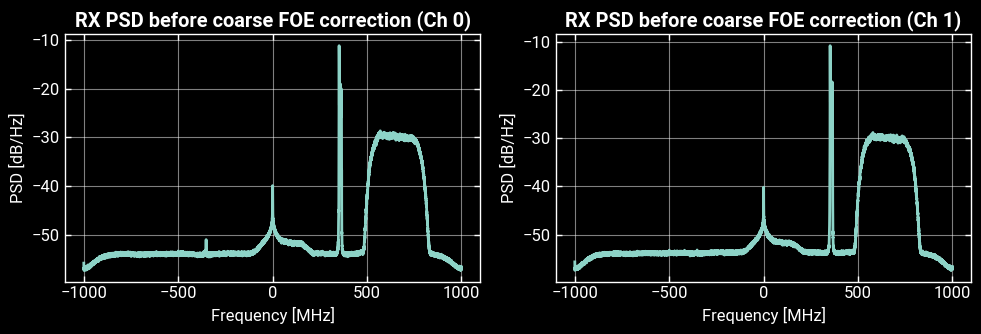

    bias-tone @ +352587523.131 MHz, applying shift = +652.591 MHz


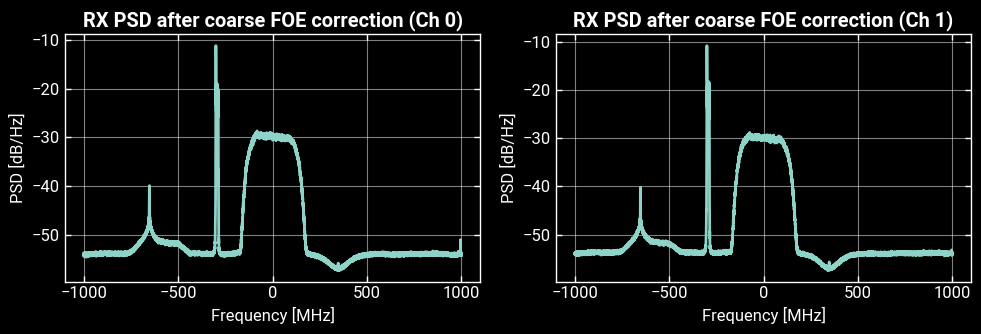

2026-05-18 19:19:25 [WARNING] [commstools/sync.py] Channel 0: Peak phase coherence is very low (0.31), but peak is visually prominent (PAPR=64.6 >= 3). This suggests strong Carrier Frequency Offset (CFO) or uncompensated dispersion destroying phase alignment over the sequence length.
2026-05-18 19:19:25 [WARNING] [commstools/sync.py] Channel 1: Peak phase coherence is very low (0.35), but peak is visually prominent (PAPR=66.4 >= 3). This suggests strong Carrier Frequency Offset (CFO) or uncompensated dispersion destroying phase alignment over the sequence length.
2026-05-18 19:19:25 [WARNING] [commstools/sync.py] Skew detected among valid channels! Valid Peaks: [59158, 59154]. Spread: 4 samples.


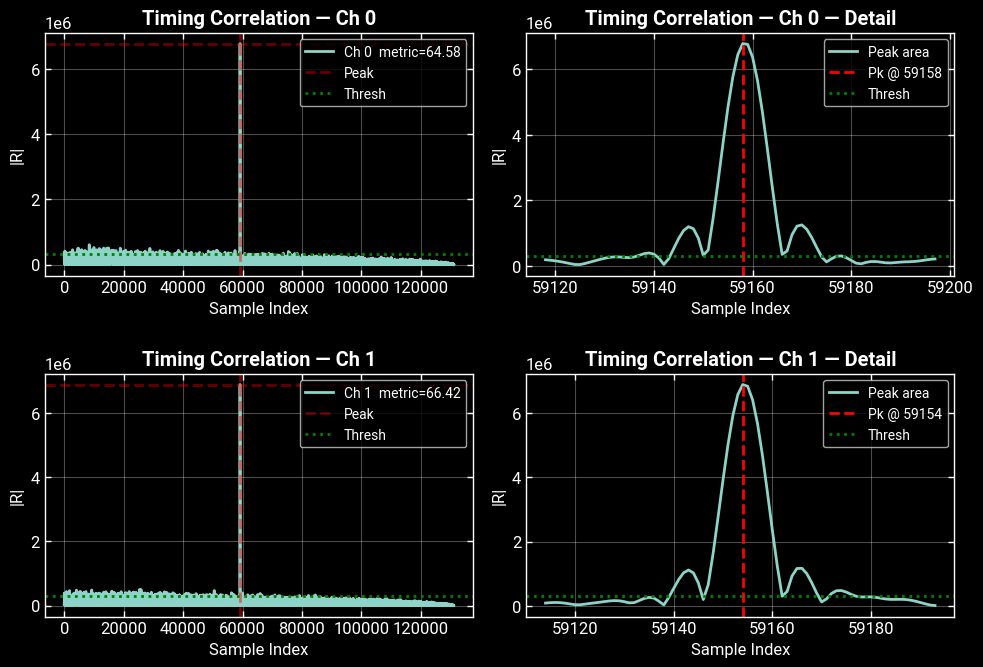

2026-05-18 19:19:26 [INFO] [commstools/sync.py] Timing estimated. Coarse: [59158, 59154], Fractional: [0.4331641242686477, 0.3562132750328686], Metrics: [64.58044650400544, 66.4245668298776]
2026-05-18 19:19:26 [WARNING] [commstools/sync.py] correct_timing(mode='slice'): output is shorter than input (trimmed by up to 59158 samples). Signal length metadata (e.g. duration) will no longer match the original.
2026-05-18 19:19:26 [INFO] [commstools/sync.py] Timing corrected: coarse=[59158, 59154], fractional=applied, mode='slice'.
    per-segment Δf:  mean = -155301.3 Hz,  std = 108322.8 Hz,  range = [-355186.7, +19040.5] Hz (39 segments)


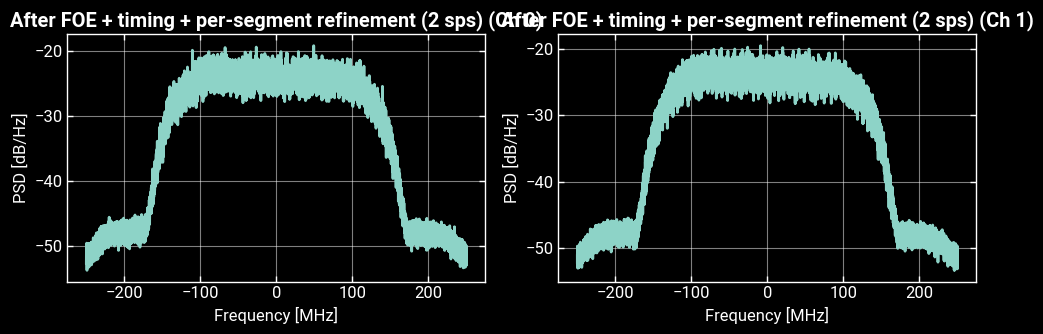

2026-05-18 19:19:26 [INFO] [commstools/core.py] Generating shaping filter taps (shape: rrc).


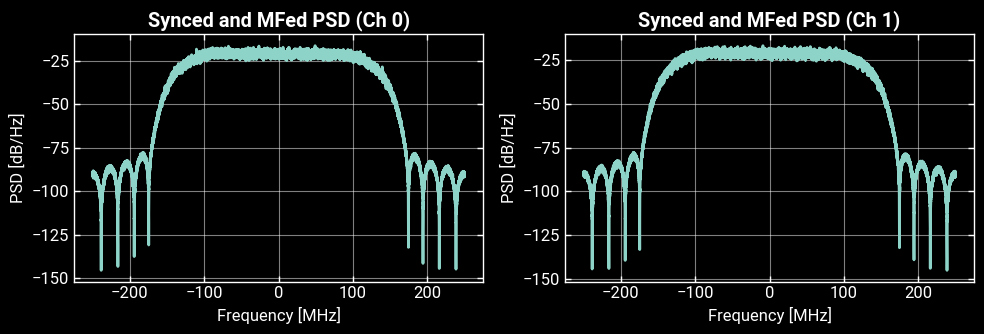

2026-05-18 19:19:26 [INFO] [commstools/equalization.py] LMS equalizer: num_taps=35, mu=0.002, sps=2.0, backend=numba, n_train=8192, cpr=bps
2026-05-18 19:19:26 [WARNING] [commstools/equalization.py] LMS output y_hat is at 1 SPS (symbol rate). Update sampling_rate = symbol_rate after applying this equalizer.
2026-05-18 19:19:26 [INFO] [commstools/equalization.py] LMS: exit MSE (final 100 symbols): ch0=0.4, ch1=0.2 dB
2026-05-18 19:19:26 [INFO] [commstools/equalization.py] LMS equalizer: num_taps=35, mu=0.002, sps=2.0, backend=numba, n_train=8192, cpr=bps
2026-05-18 19:19:26 [WARNING] [commstools/equalization.py] LMS output y_hat is at 1 SPS (symbol rate). Update sampling_rate = symbol_rate after applying this equalizer.
2026-05-18 19:19:26 [INFO] [commstools/equalization.py] LMS: exit MSE (final 100 symbols): ch0=-0.2, ch1=-0.3 dB
2026-05-18 19:19:26 [INFO] [commstools/equalization.py] LMS equalizer: num_taps=35, mu=0.002, sps=2.0, backend=numba, n_train=8192, cpr=bps
2026-05-18 19:19:2

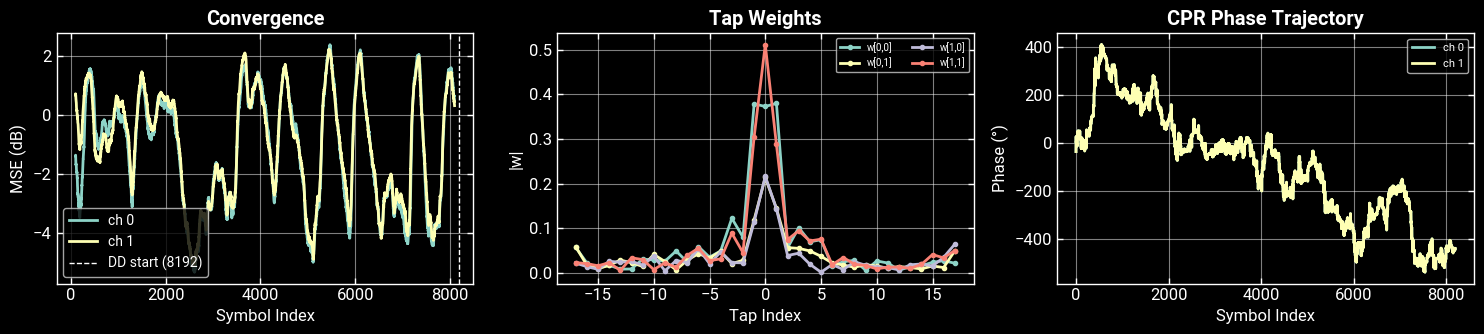

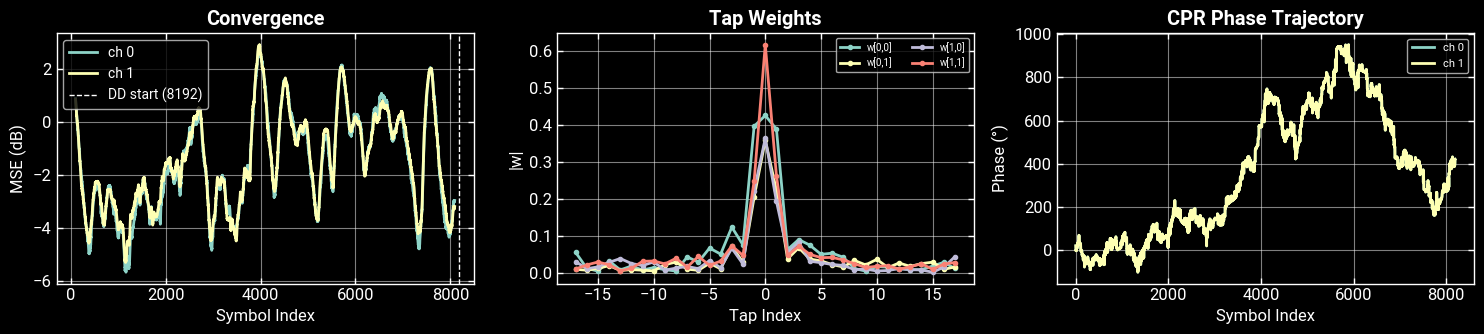

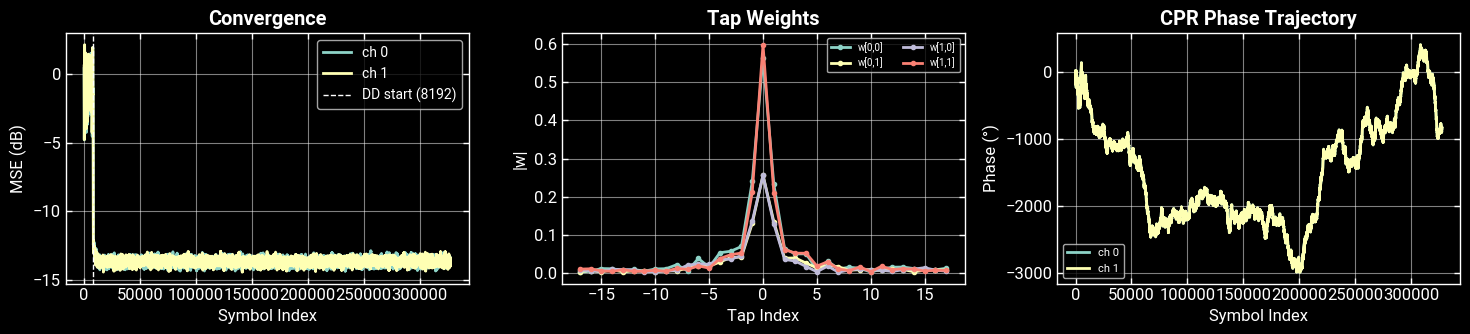

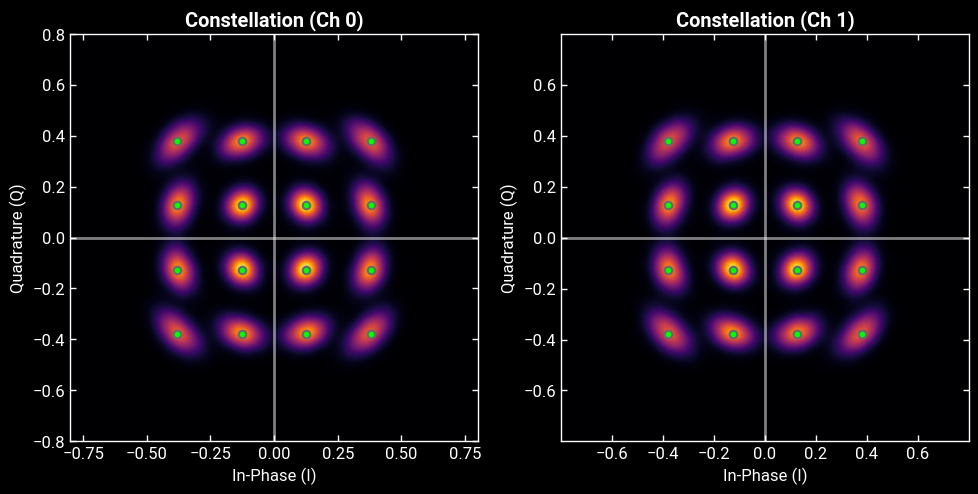

2026-05-18 19:19:33 [INFO] [commstools/sync.py] CPR (BPS, B=1024, joint): phase mean=530.70°, std=66.91° [20480 blocks x 16 symbols, C=2, cycle_slip_correction=False]


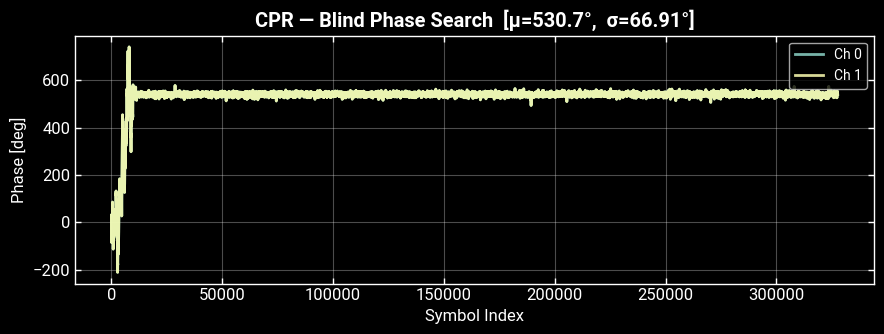

2026-05-18 19:19:33 [INFO] [commstools/core.py] Signal already at 1 sps, no downsampling needed.
2026-05-18 19:19:33 [INFO] [commstools/metrics.py] SER: 7.19e-01 (235622/327680 errors)
2026-05-18 19:19:33 [INFO] [commstools/metrics.py] SER: 4.64e-01 (151939/327680 errors)
2026-05-18 19:19:33 [INFO] [commstools/metrics.py] SER: 9.92e-01 (325179/327680 errors)
2026-05-18 19:19:34 [INFO] [commstools/metrics.py] SER: 8.42e-01 (275964/327680 errors)
2026-05-18 19:19:34 [INFO] [commstools/sync.py] Phase ambiguity resolution: ch=0, best_k=1, rotation=90.0°, SER=0.4637
2026-05-18 19:19:34 [INFO] [commstools/metrics.py] SER: 7.19e-01 (235604/327680 errors)
2026-05-18 19:19:34 [INFO] [commstools/metrics.py] SER: 4.64e-01 (151942/327680 errors)
2026-05-18 19:19:34 [INFO] [commstools/metrics.py] SER: 9.92e-01 (325207/327680 errors)
2026-05-18 19:19:34 [INFO] [commstools/metrics.py] SER: 8.42e-01 (275990/327680 errors)
2026-05-18 19:19:34 [INFO] [commstools/sync.py] Phase ambiguity resolution: ch=1

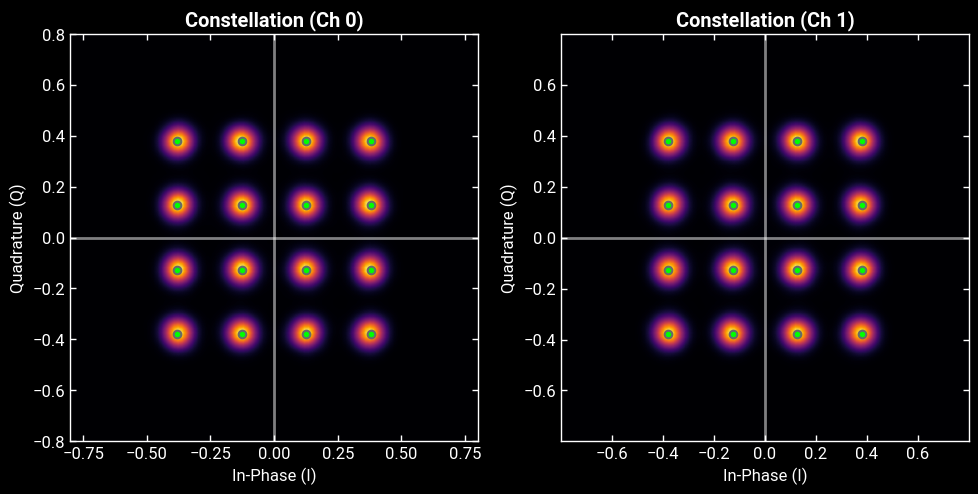

2026-05-18 19:19:34 [INFO] [commstools/core.py] Discarding 8192 training symbols for EVM calculation.
2026-05-18 19:19:34 [INFO] [commstools/metrics.py] EVM [blind] Ch0: 12.15% (-18.31 dB)
2026-05-18 19:19:34 [INFO] [commstools/metrics.py] EVM [blind] Ch1: 12.28% (-18.21 dB)
2026-05-18 19:19:34 [INFO] [commstools/core.py] Discarding 8192 training symbols for SER calculation.
2026-05-18 19:19:34 [INFO] [commstools/metrics.py] SER Ch0: 4.52e-01 (144509/319488 errors)
2026-05-18 19:19:34 [INFO] [commstools/metrics.py] SER Ch1: 4.52e-01 (144510/319488 errors)
2026-05-18 19:19:34 [INFO] [commstools/core.py] Discarding 8192 training symbols for SNR calculation.
2026-05-18 19:19:34 [INFO] [commstools/metrics.py] SNR Ch0: -0.87 dB
2026-05-18 19:19:34 [INFO] [commstools/metrics.py] SNR Ch1: -0.87 dB


array([-0.8699572, -0.873186 ], dtype=float32)

In [28]:
import jax

jax.config.update("jax_enable_x64", True)

# --------------------------------------------------------------------------
# 1. Reference TX waveform, brought to the ADC sample rate (8 sps)
# --------------------------------------------------------------------------

tx = load_npz(TX_PATH)
_, xp, sp = dispatch(tx.samples)

digoff = tx.digital_frequency_offset  # +300 MHz baked at TX
tx.shift_frequency(-digoff)  # strip it from the reference
tx.resample(up=1, down=2)  # 4 GSps → 2 GSps  (16 sps → 8 sps)
tile_len_adc = tx.samples.shape[-1]  # one DAC buffer at the ADC rate

# --------------------------------------------------------------------------
# 2. Capture: form 2-pol complex, fix IQ imbalance.
# --------------------------------------------------------------------------
rx_raw = xp.load(RX_PATH)
rx_samples = xp.array(
    [
        rx_raw[0] + 1j * rx_raw[1],
        rx_raw[2] + 1j * rx_raw[3],
    ]
)
rx_samples = compensate_iq_imbalance_lowdin(xp.conj(rx_samples))

rx = Signal(
    samples=rx_samples,
    sampling_rate=tx.sampling_rate,
    symbol_rate=tx.symbol_rate,
    mod_scheme=tx.frame.payload_mod_scheme,
    mod_order=tx.frame.payload_mod_order,
    frame=tx.frame,
    pulse_shape=tx.pulse_shape,
)

rx.plot_psd(title="RX PSD before coarse FOE correction", nperseg=2**15, show=True)

# --------------------------------------------------------------------------
# 3. Coarse FOE on the FIRST tile — drives the timing step.
#    Use the bias-leakage tone in the PSD with log-parabolic sub-bin
#    interpolation.  One sub-bin pass is enough precision for timing's
#    phase coherence; per-segment refinement comes later.
# --------------------------------------------------------------------------
f_b_coarse = find_bias_tone(rx.samples[0, :tile_len_adc], rx.sampling_rate, xp=xp)
coarse_shift = f_b_coarse + digoff  # puts bias at -digoff, signal at 0
print(
    f"    bias-tone @ {f_b_coarse:+.3f} MHz, "
    f"applying shift = {coarse_shift / 1e6:+.3f} MHz"
)
rx.samples = correct_frequency_offset(rx.samples, rx.sampling_rate, coarse_shift)

rx.plot_psd(title="RX PSD after coarse FOE correction", nperseg=2**15, show=True)

# --------------------------------------------------------------------------
# 4. Timing — first peak, slice mode.  Restrict the cross-correlation
#    search to the first 2 tiles so estimate_timing's argmax lands on the
#    FIRST tile peak (otherwise the strongest of many near-identical
#    tile-peaks wins, typically pointing deep into the capture).
# --------------------------------------------------------------------------
coarse, fract = estimate_timing(
    rx.samples,
    tx.samples,
    sps=rx.sps,
    search_range=(0, tile_len_adc),
    threshold=3,
    debug_plot=True,
)
rx.samples = correct_timing(rx.samples, coarse, fract, mode="slice")

# --------------------------------------------------------------------------
# 5. Truncate to an integer number of frames after the slice.
#    Doing this *after* the slice (not before) preserves up to one extra
#    frame relative to a pre-trim, since the raw trailing partial tile
#    can now contribute when it's bigger than `max(coarse)`.
# --------------------------------------------------------------------------
n_seg_adc = rx.samples.shape[-1] // tile_len_adc
# rx.samples = rx.samples[:, : n_seg_adc * tile_len_adc]
rx.samples = rx.samples[:, : 20 * tile_len_adc]


# --------------------------------------------------------------------------
# 6. Per-segment refined FOE with a continuous-phase trajectory.
#    Search around the post-coarse bias-tone location (-digoff) in each
#    segment, compute the residual drift, cubic-spline-interpolate, and
#    integrate to a per-sample phase array applied via
#    correct_carrier_phase.  No phase discontinuities at boundaries.
# --------------------------------------------------------------------------
def per_segment_estimator(blk, fs):
    # After the coarse correction, the bias tone sits near -digoff.
    # Any deviation = the residual frequency drift to be removed.
    f_b_k = find_bias_tone(
        blk,
        fs,
        xp=xp,
        target_hz=-digoff,
        search_band_hz=20e6,  # ±20 MHz around -digoff is well clear of the signal
    )
    return f_b_k + digoff  # δf_k = current bias offset relative to target


theta = piecewise_carrier_phase(
    rx.samples[0, :],  # just one pol for FOE estimation
    rx.sampling_rate,
    block_size=tile_len_adc,
    overlap=0.5,
    estimator=per_segment_estimator,
    xp=xp,
    sp=sp,
)
rx.samples = correct_carrier_phase(rx.samples, theta)

# --------------------------------------------------------------------------
# 7. Resample reference and capture to 2 sps; the polyphase anti-alias
#    filter kills the now-stationary bias tone at -digoff = -300 MHz
#    (outside ±250 MHz Nyquist at 500 MSps).
# --------------------------------------------------------------------------
rx.resample(sps_out=2)
tx.resample(sps_out=2)
n_seg = rx.samples.shape[-1] // tx.samples.shape[-1]

rx.plot_psd(
    show=True,
    title="After FOE + timing + per-segment refinement (2 sps)",
    nperseg=2**15,
)

# --------------------------------------------------------------------------
# 8. Matched filter + tile source bits/symbols to the aligned frame count.
# --------------------------------------------------------------------------
rx.source_bits = xp.tile(tx.frame.payload_bits, (1, n_seg))
rx.source_symbols = xp.tile(tx.frame.payload_symbols, (1, n_seg))
rx.matched_filter()
rx.plot_psd(show=True, title="Synced and MFed PSD", nperseg=2**15)

# --------------------------------------------------------------------------
# 9. Iterative warm-started butterfly LMS with BPS CPR.
#    Known limitation: CPR state resets to 0 on every block_lms entry.
# --------------------------------------------------------------------------

block = False

if block:
    NUM_EQ = 5
    NUM_TRAIN = 2**13
    NUM_TAPS = 35
    BLOCK_SIZE = 128
    STEP_SIZE = 2e-4

    eq_kwargs = dict(
        modulation=rx.mod_scheme,
        order=rx.mod_order,
        num_taps=NUM_TAPS,
        step_size=STEP_SIZE,
        sps=rx.sps,
        block_size=BLOCK_SIZE,
        cpr_type="bps",
        cpr_bps_joint_channels=True,
        cpr_bps_test_phases=512,
        cpr_bps_block_size=16,
        cpr_cycle_slip_correction=True,
        cpr_cycle_slip_history=32,
        cpr_cycle_slip_threshold=xp.pi / 4,
        plot_smoothing=200,
    )

    res = None
    for i in range(NUM_EQ):
        res = block_lms(
            samples=rx.samples[:, : NUM_TRAIN * 2],
            training_symbols=rx.source_symbols[:, :NUM_TRAIN],
            w_init=res.weights if res is not None else None,
            debug_plot=(i == 0 or i == NUM_EQ - 1),
            **eq_kwargs,
        )

    # Final pass over the full sequence — pass training too (Issue A workaround).
    res = block_lms(
        samples=rx.samples,
        training_symbols=rx.source_symbols[:, :NUM_TRAIN],
        w_init=res.weights,
        input_norm_factor=res.input_norm_factor if res is not None else None,
        debug_plot=True,
        **eq_kwargs,
    )

    eq = rx.copy()
    eq.samples = res.y_hat
    eq.sampling_rate = rx.symbol_rate
    eq.plot_constellation(show=True, overlay_ideal=True)
else:
    NUM_EQ = 6
    NUM_TRAIN = 2**13
    NUM_TAPS = 35
    STEP_SIZE = 2e-3

    eq_kwargs = dict(
        modulation=rx.mod_scheme,
        order=rx.mod_order,
        num_taps=NUM_TAPS,
        step_size=STEP_SIZE,
        sps=rx.sps,
        cpr_type="bps",
        cpr_joint_channels=True,
        cpr_bps_test_phases=1024,
        cpr_bps_block_size=32,
        cpr_cycle_slip_correction=True,
        cpr_cycle_slip_history=32,
        cpr_cycle_slip_threshold=xp.pi / 4,
        plot_smoothing=200,
        backend="numba",
    )

    res = None
    for i in range(NUM_EQ):
        res = lms(
            samples=rx.samples[:, : NUM_TRAIN * 2],
            training_symbols=rx.source_symbols[:, :NUM_TRAIN],
            w_init=res.weights if res is not None else None,
            # input_norm_factor=res.input_norm_factor if res is not None else None,
            # cpr_state=res.cpr_state if res is not None else None,
            debug_plot=(i == 0 or i == NUM_EQ - 1),
            **eq_kwargs,
        )

    # Final pass over the full sequence — pass training too (Issue A workaround).
    res = lms(
        samples=rx.samples,
        training_symbols=rx.source_symbols[:, :NUM_TRAIN],
        w_init=res.weights if res is not None else None,
        input_norm_factor=res.input_norm_factor if res is not None else None,
        # cpr_state=res.cpr_state if res is not None else None,
        debug_plot=True,
        **eq_kwargs,
    )

    eq = rx.copy()
    eq.samples = res.y_hat
    eq.sampling_rate = rx.symbol_rate
    eq.plot_constellation(show=True, overlay_ideal=True)

# --------------------------------------------------------------------------
# 10. Standalone BPS-CPR on the equalized output, then phase ambiguity
#     resolution and hard demap.
# --------------------------------------------------------------------------
phases_bps = recover_carrier_phase_bps(
    eq.samples,
    modulation=eq.mod_scheme,
    order=eq.mod_order,
    debug_plot=True,
    block_size=16,
    num_test_phases=1024,
    cycle_slip_correction=False,
    cycle_slip_history=128,
    cycle_slip_threshold=xp.pi / 4,
    joint_channels=True,
)

eqfoecpr = eq.copy()
eqfoecpr.samples = correct_carrier_phase(eqfoecpr.samples, phases_bps)
eqfoecpr.resolve_symbols()
eqfoecpr.resolve_phase_ambiguity()
eqfoecpr.demap_symbols_hard()
eqfoecpr.plot_constellation(show=True, overlay_ideal=True)

# --------------------------------------------------------------------------
# 11. Metrics.  EVM "blind" measures blob size against the nearest
#     constellation point.  SER/SNR discard `2 × NUM_TRAIN` symbols to
#     skip past the post-training CPR convergence region (Issue A).
# --------------------------------------------------------------------------
eqfoecpr.evm(num_train_symbols=NUM_TRAIN, mode="blind")
eqfoecpr.ser(num_train_symbols=NUM_TRAIN)
eqfoecpr.snr(num_train_symbols=NUM_TRAIN)
